# 07 · Uncertainty II — Deep Ensemble

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/07_deep_ensemble.ipynb)

Train M surrogates from different seeds/bootstraps; their disagreement is the predictive uncertainty. Usually better-calibrated than MC-Dropout, at M× the training cost (still seconds here).

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate, SurrogateEnsemble)
symlog = SymlogTransform(I0=1e-6)
biases = np.linspace(0.0, 0.6, 13)
profiles = [step(L) for L in np.geomspace(5e20, 5e22, 11)]
X, Y = build_sg_dataset(profiles, biases, scaling, sg, symlog); norm = Normalizer.fit(X)
members=[]
for m in range(5):
    net = IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR, hidden=128, n_layers=3, seed=m))
    rs = np.random.RandomState(m); idx = rs.randint(0,len(X),len(X))
    train_surrogate(net, X[idx], Y[idx], norm, epochs=2000, lr=2e-3); members.append(net)
ens = SurrogateEnsemble(members, norm, symlog)
print(f"ensemble of {ens.M}")


ensemble of 5


## Ensemble uncertainty band

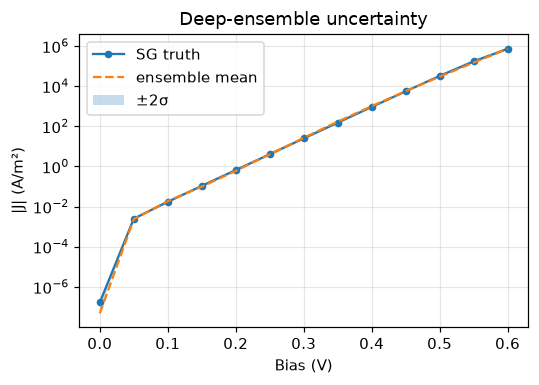

In [3]:

C = step(1.7e21); pred = ens.predict(scaling.doping_to_net_input(C), biases/VT)
lo = symlog.inverse(pred.mean_symlog-2*pred.std_symlog)
hi = symlog.inverse(pred.mean_symlog+2*pred.std_symlog)
Isg = sg_iv(C, biases)
plt.figure(figsize=(5,3.6))
plt.semilogy(biases, np.abs(Isg), "o-", label="SG truth", ms=4)
plt.semilogy(biases, np.abs(pred.mean_current), "--", label="ensemble mean")
plt.fill_between(biases, np.abs(lo), np.abs(hi), alpha=0.25, label="±2σ")
plt.xlabel("Bias (V)"); plt.ylabel("|J| (A/m²)"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Deep-ensemble uncertainty"); plt.tight_layout(); plt.show()
